# Week 6: Polynomial Regression, Overfitting & Regularization

## Student Practice Notebook

**Name:** M. Sukanya
**Roll Number:** AP24110011837
**Date:** 11/09/2026

## Learning Objectives

After completing this lab, you will be able to:

- Engineer polynomial features and fit non-linear relationships with linear regression
- Recognize underfitting and overfitting from train vs. test performance
- Explain the bias-variance tradeoff in your own words
- Apply Ridge (L2), Lasso (L1), and ElasticNet regularization to fix an overfit model
- Explain why Lasso can zero out weights entirely while Ridge only shrinks them

### Why this week matters
Last week's linear model assumed a straight-line relationship. Real relationships often curve. This week you'll see what happens when a model gets too flexible — and how regularization reins it back in. This is the single most useful skill for making any model in your capstone project generalize, not just memorize.


## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

%matplotlib inline
np.random.seed(1)


## Part 1 — Polynomial Regression

### 1.1 Demo: a curved relationship


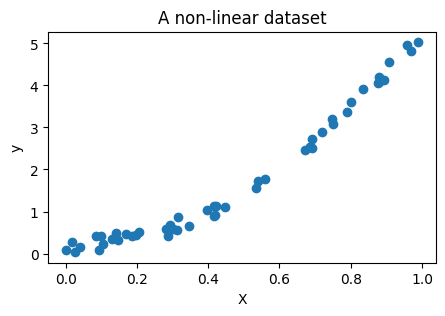

In [2]:
X_demo = np.random.rand(50, 1)
y_demo = (
    0.7 * X_demo ** 5 - 2.1 * X_demo ** 4 + 2.7 * X_demo ** 3
    + 3.5 * X_demo ** 2 + 0.3 * X_demo + 0.4 * np.random.rand(50, 1)
)

plt.figure(figsize=(5, 3))
plt.scatter(X_demo, y_demo)
plt.xlabel('X')
plt.ylabel('y')
plt.title('A non-linear dataset')
plt.show()


### 1.2 Fitting a plain (degree-1) line — does it work?

R2: 0.9345996128366808


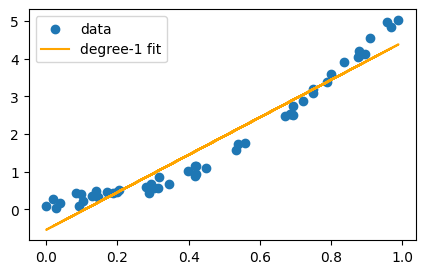

In [3]:
lin = LinearRegression()
lin.fit(X_demo, y_demo)
pred = lin.predict(X_demo)

print('R2:', lin.score(X_demo, y_demo))

plt.figure(figsize=(5, 3))
plt.scatter(X_demo, y_demo, label='data')
plt.plot(X_demo, pred, color='orange', label='degree-1 fit')
plt.legend()
plt.show()


**Predict, then think:** before running the next cell, guess — will a degree-2 polynomial fit noticeably better? Why or why not?

*Your answer:* Yes, I think a degree-2 polynomial will fit better than a straight line because the data is curved. A degree-2 polynomial can create a curve, so it should follow the data points more closely.


### Student Practice — fit a degree-3 polynomial

Use `PolynomialFeatures(degree=3, include_bias=False)` to transform `X_demo`, then fit a `LinearRegression` on the transformed features. Plot the result like the demo above (tip: sort `X_demo` before plotting the line, or the plot will look jagged).


R2: 0.994924691754525


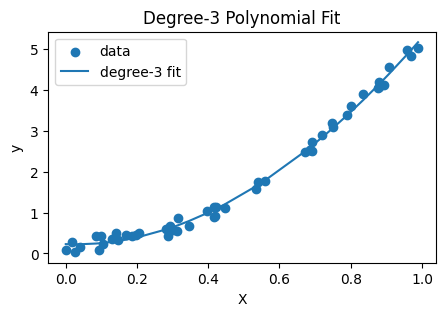

In [4]:
# Write your answer here
poly = PolynomialFeatures(degree=3, include_bias=False)

X_poly = poly.fit_transform(X_demo)
poly_model = LinearRegression()
poly_model.fit(X_poly, y_demo)
y_poly_pred = poly_model.predict(X_poly)
print('R2:', poly_model.score(X_poly, y_demo))
sort_idx = X_demo[:, 0].argsort()

plt.figure(figsize=(5, 3))

plt.scatter(X_demo, y_demo, label='data')

plt.plot(
    X_demo[sort_idx],
    y_poly_pred[sort_idx],
    label='degree-3 fit'
)

plt.xlabel('X')
plt.ylabel('y')
plt.title('Degree-3 Polynomial Fit')
plt.legend()
plt.show()

## Part 2 — The Bias-Variance Tradeoff

We'll sweep polynomial degree from 1 to 25 on a train/test split, and watch what happens to train vs. test performance.


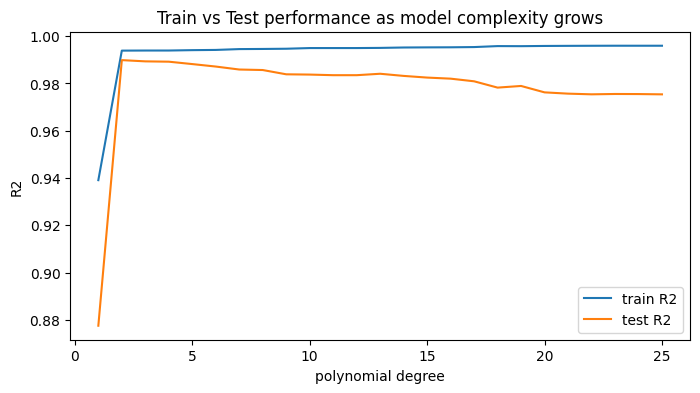

In [5]:
np.random.seed(1)
X_bv = np.random.rand(100, 1)
y_bv = (
    0.7 * X_bv ** 5 - 2.1 * X_bv ** 4 + 2.7 * X_bv ** 3
    + 3.5 * X_bv ** 2 + 0.3 * X_bv + 0.4 * np.random.rand(100, 1)
)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bv, y_bv, test_size=0.3, random_state=1)

train_scores, test_scores = [], []
degrees = range(1, 26)

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xb_train_d = poly.fit_transform(Xb_train)
    Xb_test_d = poly.transform(Xb_test)

    m = LinearRegression()
    m.fit(Xb_train_d, yb_train)

    train_scores.append(m.score(Xb_train_d, yb_train))
    test_scores.append(m.score(Xb_test_d, yb_test))

plt.figure(figsize=(8, 4))
plt.plot(list(degrees), train_scores, label='train R2')
plt.plot(list(degrees), test_scores, label='test R2')
plt.xlabel('polynomial degree')
plt.ylabel('R2')
plt.legend()
plt.title('Train vs Test performance as model complexity grows')
plt.show()


### Student Practice — find the sweet spot

From the plot above (or by printing `test_scores`), find the degree with the **highest test R²**. Print that degree and its test score.


In [6]:
# Write your answer here
best_degree = degrees[np.argmax(test_scores)]
best_score = max(test_scores)

print("Best degree:", best_degree)
print("Highest test R2:", best_score)

Best degree: 2
Highest test R2: 0.9898365606379398


**Reflection:** In your own words, what is *bias* and what is *variance*? At low degree, which one is high? At high degree, which one is high?

*Your answer:* Bias is when the model is too simple and cannot understand the data properly. Variance is when the model is too sensitive to the training data and overfits. At low degree, bias is high. At high degree, variance is high.


## Part 3 — Regularization: Fixing an Overfit Model

We just saw high-degree polynomials overfit — they drive training error to near-zero by chasing noise. Regularization fights this by **penalizing large weights** directly in the loss function:

$$\text{Loss} = \text{MSE}(y, \hat{y}) + \lambda \times \text{penalty}(W)$$

- **Ridge (L2):** penalty = $\sum w_j^2$ — shrinks all weights smoothly toward zero, rarely exactly zero.
- **Lasso (L1):** penalty = $\sum |w_j|$ — can push weights **exactly to zero** (automatic feature selection). This happens because L1's penalty keeps pulling by the same fixed amount even as a weight nears zero, while L2's pull weakens the closer the weight already is to zero.
- **ElasticNet:** a blend of both, controlled by `l1_ratio`.

### 3.1 Demo: deliberately overfit, then rescue with Ridge/Lasso


In [ ]:
overfit_degree = 25
poly_of = PolynomialFeatures(degree=overfit_degree, include_bias=False)
Xb_train_of = poly_of.fit_transform(Xb_train)
Xb_test_of = poly_of.transform(Xb_test)

# Regularization penalizes weight MAGNITUDE, so features must be on comparable scales first
poly_scaler = StandardScaler()
Xb_train_of_scaled = poly_scaler.fit_transform(Xb_train_of)
Xb_test_of_scaled = poly_scaler.transform(Xb_test_of)

plain_of = LinearRegression()
plain_of.fit(Xb_train_of_scaled, yb_train)

print('Plain Linear Regression, degree =', overfit_degree)
print('  Train MSE:', mean_squared_error(yb_train, plain_of.predict(Xb_train_of_scaled)))
print('  Test  MSE:', mean_squared_error(yb_test, plain_of.predict(Xb_test_of_scaled)))


In [ ]:
ridge_of = Ridge(alpha=1.0)
lasso_of = Lasso(alpha=0.01)
elastic_of = ElasticNet(alpha=0.01, l1_ratio=0.5)

for name, m in [('Ridge', ridge_of), ('Lasso', lasso_of), ('ElasticNet', elastic_of)]:
    m.fit(Xb_train_of_scaled, yb_train)
    train_mse = mean_squared_error(yb_train, m.predict(Xb_train_of_scaled))
    test_mse = mean_squared_error(yb_test, m.predict(Xb_test_of_scaled))
    print(f'{name:10s}  train MSE={train_mse:.5f}   test MSE={test_mse:.5f}')


### Student Practice — tune the regularization strength

Try **three different values of `alpha`** for Ridge (e.g. 0.01, 1.0, 100.0). For each, fit, and print train/test MSE. Which `alpha` gives the best (lowest) test MSE? What happens at the extremes (too small or too large)?


In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Create data
np.random.seed(1)

X_bv = np.random.rand(100, 1)

y_bv = (
    0.7 * X_bv ** 5
    - 2.1 * X_bv ** 4
    + 2.7 * X_bv ** 3
    + 3.5 * X_bv ** 2
    + 0.3 * X_bv
    + 0.4 * np.random.rand(100, 1)
)

# Train-test split
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bv, y_bv, test_size=0.3, random_state=1
)

# Degree-25 polynomial
poly_of = PolynomialFeatures(degree=25, include_bias=False)

Xb_train_of = poly_of.fit_transform(Xb_train)
Xb_test_of = poly_of.transform(Xb_test)

# Scale features
poly_scaler = StandardScaler()

Xb_train_of_scaled = poly_scaler.fit_transform(Xb_train_of)
Xb_test_of_scaled = poly_scaler.transform(Xb_test_of)

# Try different alpha values
alphas = [0.01, 1.0, 100.0]

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(Xb_train_of_scaled, yb_train)

    train_mse = mean_squared_error(
        yb_train,
        ridge.predict(Xb_train_of_scaled)
    )

    test_mse = mean_squared_error(
        yb_test,
        ridge.predict(Xb_test_of_scaled)
    )

    print(f'alpha={alpha}  train MSE={train_mse:.5f}  test MSE={test_mse:.5f}')

alpha=0.01  train MSE=0.01475  test MSE=0.01850
alpha=1.0  train MSE=0.01678  test MSE=0.02249
alpha=100.0  train MSE=0.19633  test MSE=0.20515


### 3.2 L1 vs L2: sparsity in practice


In [ ]:
n_zero_lasso = np.sum(np.isclose(lasso_of.coef_, 0))
n_zero_ridge = np.sum(np.isclose(ridge_of.coef_, 0))

print(f'Lasso: {n_zero_lasso} / {len(lasso_of.coef_)} weights driven to (near) zero')
print(f'Ridge: {n_zero_ridge} / {len(ridge_of.coef_)} weights driven to (near) zero')


**Reflection:** Based on the alpha values you tried, explain in your own words why "too small alpha" and "too large alpha" are both bad — and connect this to bias-variance from Part 2.

*Your answer:* Too small alpha means weak regularization, so the model can overfit → low bias, high variance.
Too large alpha makes the model too simple and causes underfitting → high bias, low variance.



## Summary

| What we did | Why it matters |
|---|---|
| Polynomial features | Fit curved relationships while still using linear regression under the hood |
| Bias-variance sweep | Low degree = underfit (high bias); high degree = overfit (high variance) |
| Ridge / Lasso / ElasticNet | Penalize large weights to curb overfitting; Lasso can also select features |

**In your capstone project:** if your model's train score is much higher than its test score, that's overfitting — this week's regularization toolkit is your first fix to reach for, before assuming you need a fancier model.

**Optional, not required:** an advanced enrichment notebook covering hand-coded gradient descent, `statsmodels` OLS, and regression-assumption diagnostics (VIF, residual normality, heteroskedasticity) is available separately for anyone who wants to go deeper — not part of this week's grading.
